# NB09: Genomic Carbon Source Extension — Predicted Prebiotic Candidates

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Use GapMind pathway predictions (80 pathways) and patient metatranscriptomics (220 KEGG pathways) to identify carbon sources beyond the 22 tested experimentally that could serve as selective prebiotics.

## Strategy
NB06 showed PA14 outgrows commensals on all 22 tested substrates. But GapMind covers ~80 pathways and KEGG metatranscriptomics covers 220 — many untested. We look for:
1. Pathways where core formulation species have COMPLETE predictions but PA14 does NOT
2. Pathways actively expressed by commensals in patient lungs (metatranscriptomics) but not by PA14
3. Pathways unique to lung-adapted genomes of our formulation species

**Requires**: BERDL Spark + local patient metatranscriptomics

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data')
FIGS = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/figures')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load pangenome conservation from NB07
conservation = pd.read_csv(DATA / 'pangenome_conservation.tsv', sep='\t')
print(f'Pangenome conservation: {len(conservation)} species × pathway entries')
print(f'Species: {conservation.species.unique().tolist()}')

Pangenome conservation: 400 species × pathway entries
Species: ['Neisseria mucosa', 'Streptococcus salivarius', 'Micrococcus luteus', 'Rothia dentocariosa', 'Gemella sanguinis']


## 1. GapMind Pathway Comparison: Commensals vs PA14

Query GapMind for P. aeruginosa and compare pathway completeness against our 5 core commensal species.

In [2]:
# Find PA14/PAO1 clade in pangenome
pa_clades = spark.sql("""
    SELECT DISTINCT gtdb_species_clade_id, COUNT(*) as n
    FROM kbase_ke_pangenome.genome
    WHERE gtdb_species_clade_id LIKE 's__Pseudomonas_aeruginosa%'
    GROUP BY gtdb_species_clade_id
""").toPandas()
print('P. aeruginosa clades in pangenome:')
print(pa_clades.to_string())

pa_clade = pa_clades.iloc[0]['gtdb_species_clade_id']
print(f'\nUsing: {pa_clade}')

P. aeruginosa clades in pangenome:
                             gtdb_species_clade_id     n
0    s__Pseudomonas_aeruginosa--RS_GCF_001457615.1  6760
1  s__Pseudomonas_aeruginosa_A--RS_GCF_000017205.1    43

Using: s__Pseudomonas_aeruginosa--RS_GCF_001457615.1


In [3]:
# Get PA GapMind pathway conservation
print(f'Querying GapMind for P. aeruginosa...')
pa_gm = spark.sql(f"""
    WITH scored AS (
        SELECT genome_id, pathway, metabolic_category,
            CASE score_category
                WHEN 'complete' THEN 5
                WHEN 'likely_complete' THEN 4
                WHEN 'steps_missing_low' THEN 3
                WHEN 'steps_missing_medium' THEN 2
                WHEN 'not_present' THEN 1
                ELSE 0
            END AS score_val
        FROM kbase_ke_pangenome.gapmind_pathways
        WHERE clade_name = '{pa_clade}'
    ),
    best AS (
        SELECT genome_id, pathway, metabolic_category, MAX(score_val) AS best_score
        FROM scored GROUP BY genome_id, pathway, metabolic_category
    )
    SELECT pathway, metabolic_category,
        COUNT(DISTINCT genome_id) AS n_genomes,
        CAST(AVG(CASE WHEN best_score >= 4 THEN 1.0 ELSE 0.0 END) AS DOUBLE) AS frac_complete,
        CAST(AVG(best_score) AS DOUBLE) AS mean_score
    FROM best
    GROUP BY pathway, metabolic_category
""").toPandas()
pa_gm['species'] = 'Pseudomonas aeruginosa'
print(f'PA pathways: {len(pa_gm)}, genomes: {pa_gm.n_genomes.iloc[0]}')

Querying GapMind for P. aeruginosa...


PA pathways: 80, genomes: 6760


In [4]:
# Combine PA with commensal conservation data
all_conservation = pd.concat([conservation, pa_gm], ignore_index=True)

# Pivot: species x pathway completeness
pivot = all_conservation.pivot_table(index='pathway', columns='species', values='frac_complete')

# Find pathways where commensals are complete but PA is NOT
core_species = ['Neisseria mucosa', 'Streptococcus salivarius', 'Micrococcus luteus',
                'Rothia dentocariosa', 'Gemella sanguinis']

# For each pathway: max commensal completeness vs PA completeness
pivot['max_commensal'] = pivot[core_species].max(axis=1)
pivot['n_commensals_complete'] = (pivot[core_species] > 0.9).sum(axis=1)
pivot['pa_complete'] = pivot.get('Pseudomonas aeruginosa', 0)
pivot['selectivity'] = pivot['max_commensal'] - pivot['pa_complete']

# Best prebiotic candidates: high commensal completeness, low PA completeness
candidates = pivot[(pivot.max_commensal > 0.8) & (pivot.pa_complete < 0.5)].sort_values('selectivity', ascending=False)

print(f'Pathways where commensals are complete (>80%) but PA is incomplete (<50%): {len(candidates)}')
if len(candidates) > 0:
    print(candidates[['max_commensal', 'n_commensals_complete', 'pa_complete', 'selectivity']].round(2).to_string())
else:
    print('\nNo strongly selective pathways found. Checking weaker selectivity...')
    weaker = pivot[(pivot.max_commensal > 0.5) & (pivot.pa_complete < pivot.max_commensal - 0.2)].sort_values('selectivity', ascending=False)
    print(f'Pathways with >20% selectivity gap: {len(weaker)}')
    if len(weaker) > 0:
        print(weaker[['max_commensal', 'n_commensals_complete', 'pa_complete', 'selectivity']].head(20).round(2).to_string())

Pathways where commensals are complete (>80%) but PA is incomplete (<50%): 6
species      max_commensal  n_commensals_complete  pa_complete  selectivity
pathway                                                                    
xylitol                1.0                      2         0.00         1.00
myoinositol            1.0                      1         0.00         1.00
xylose                 1.0                      2         0.00         1.00
arabinose              1.0                      2         0.00         1.00
fucose                 1.0                      2         0.01         0.99
rhamnose               1.0                      2         0.01         0.99


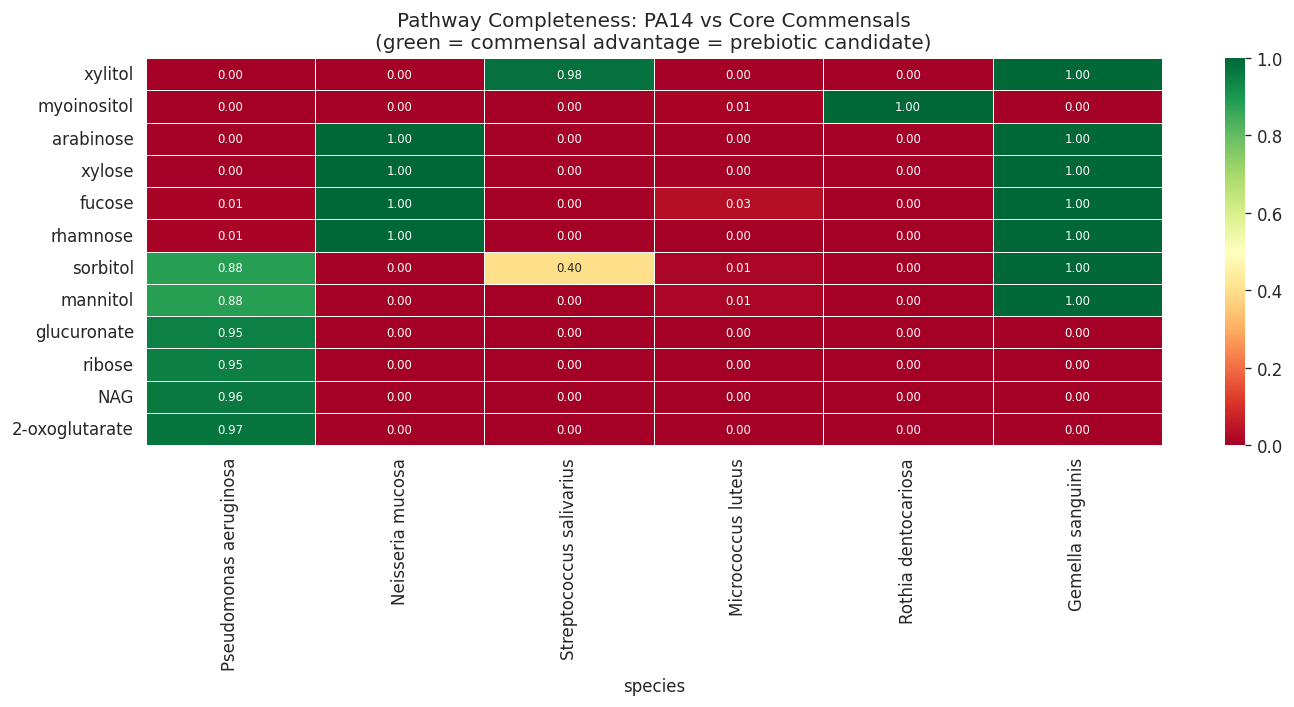

In [5]:
# Visualization: pathway selectivity heatmap
# Show pathways with any selectivity gap
show_pathways = pivot[pivot.selectivity.abs() > 0.1].sort_values('selectivity', ascending=False).index
if len(show_pathways) > 30:
    show_pathways = show_pathways[:30]

plot_species = ['Pseudomonas aeruginosa'] + core_species
plot_cols = [s for s in plot_species if s in pivot.columns]
plot_data = pivot.loc[show_pathways, plot_cols]

fig, ax = plt.subplots(figsize=(12, max(6, len(show_pathways) * 0.35)))
sns.heatmap(plot_data, cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 7})
ax.set_title('Pathway Completeness: PA14 vs Core Commensals\n(green = commensal advantage = prebiotic candidate)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGS / '09_pathway_selectivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Metatranscriptomic Evidence: Which Pathways Are Active In Vivo?

Cross-reference GapMind predictions with KEGG pathway expression from patient metatranscriptomics to find pathways that are both genomically present and actively expressed.

In [6]:
# Load species-level KEGG pathway expression
kegg = pd.read_parquet(GOLD / 'fact_species_kegg_pathway_cpm.snappy.parquet')
print(f'KEGG pathway expression: {len(kegg)} rows, {kegg.species.nunique()} species, {kegg.pathway.nunique()} pathways')

# Filter to core formulation species and PA
target_species = core_species + ['Pseudomonas aeruginosa']
# Species names in KEGG may differ from GTDB — find matches
kegg_species = kegg.species.unique()
print(f'\nSearching for formulation species in KEGG data...')
matches = {}
for sp in target_species:
    # Try exact and partial matches
    exact = [k for k in kegg_species if sp.lower() in k.lower()]
    if exact:
        matches[sp] = exact
        print(f'  {sp}: {exact}')
    else:
        # Try genus only
        genus = sp.split()[0]
        genus_match = [k for k in kegg_species if genus.lower() in k.lower()]
        if genus_match:
            matches[sp] = genus_match
            print(f'  {sp}: genus match -> {genus_match[:3]}')
        else:
            print(f'  {sp}: NOT FOUND')

KEGG pathway expression: 1133976 rows, 130 species, 405 pathways

Searching for formulation species in KEGG data...
  Neisseria mucosa: ['Neisseria mucosa']
  Streptococcus salivarius: ['Streptococcus salivarius']
  Micrococcus luteus: NOT FOUND
  Rothia dentocariosa: ['Rothia dentocariosa']
  Gemella sanguinis: ['Gemella sanguinis']
  Pseudomonas aeruginosa: ['Pseudomonas aeruginosa']


In [7]:
# Compare PA vs commensal pathway expression in patient samples
kegg['cpm'] = pd.to_numeric(kegg['cpm'], errors='coerce')

# PA expression
pa_kegg_names = matches.get('Pseudomonas aeruginosa', [])
pa_expr = kegg[kegg.species.isin(pa_kegg_names)].groupby('pathway')['cpm'].mean()

# Commensal expression (union of all matched species)
comm_kegg_names = []
for sp in core_species:
    comm_kegg_names.extend(matches.get(sp, []))
comm_expr = kegg[kegg.species.isin(comm_kegg_names)].groupby('pathway')['cpm'].mean()

# Find pathways with high commensal expression but low PA expression
expr_compare = pd.DataFrame({
    'commensal_cpm': comm_expr,
    'pa_cpm': pa_expr
}).fillna(0)
expr_compare['selectivity'] = expr_compare['commensal_cpm'] - expr_compare['pa_cpm']
expr_compare['ratio'] = (expr_compare['commensal_cpm'] + 1) / (expr_compare['pa_cpm'] + 1)

# Top commensal-selective pathways
comm_selective = expr_compare[expr_compare.ratio > 2].sort_values('ratio', ascending=False)
print(f'Pathways with >2x commensal/PA expression ratio: {len(comm_selective)}')
print(comm_selective.head(20).round(1).to_string())

Pathways with >2x commensal/PA expression ratio: 47
                                                                                                                        commensal_cpm  pa_cpm  selectivity  ratio
pathway                                                                                                                                                          
PTS system, arbutin-like II component [PATH:map02060] [BR:ko02000]                                                              828.4     0.0        828.4  829.4
PTS system, maltose-specific II component [PATH:map00500 map02060] [BR:ko02000]                                                 828.4     0.0        828.4  829.4
PTS system, maltose and glucose-specific II component [PATH:map00010 map00500 map00520 map02060] [BR:ko02000]                   828.4     0.0        828.4  829.4
PTS system, trehalose-specific II component [PATH:map00500 map02060] [BR:ko02000]                                               828.4     

In [8]:
# Combine genomic (GapMind) and transcriptomic (KEGG) evidence
# Pathways that are:
# 1. Genomically complete in commensals but not PA (from GapMind)
# 2. Actively expressed by commensals in patient lungs (from metatranscriptomics)

print('=== INTEGRATED PREBIOTIC CANDIDATES ===')
print('Criteria: genomically complete in commensals + actively expressed in vivo + not PA-preferred\n')

# GapMind candidates (from above)
genomic_candidates = set(candidates.index) if len(candidates) > 0 else set()
# Transcriptomic candidates (ratio > 2)
expr_candidates = set(comm_selective.index)

# Note: GapMind pathway names may not match KEGG pathway names directly
# Show both lists for manual cross-reference
print(f'Genomic candidates (GapMind, commensal-selective): {len(genomic_candidates)}')
for p in sorted(genomic_candidates):
    print(f'  {p}')

print(f'\nTranscriptomic candidates (KEGG, commensal expression > 2x PA): {len(expr_candidates)}')
for p in sorted(list(expr_candidates))[:20]:
    r = expr_compare.loc[p]
    print(f'  {p}: comm={r.commensal_cpm:.0f} PA={r.pa_cpm:.0f} ratio={r.ratio:.1f}')

=== INTEGRATED PREBIOTIC CANDIDATES ===
Criteria: genomically complete in commensals + actively expressed in vivo + not PA-preferred

Genomic candidates (GapMind, commensal-selective): 6
  arabinose
  fucose
  myoinositol
  rhamnose
  xylitol
  xylose

Transcriptomic candidates (KEGG, commensal expression > 2x PA): 47
  AgrC-AgrA (exoprotein synthesis) two-component regulatory system [PATH:map02020] [BR:ko02022]: comm=277 PA=0 ratio=278.1
  Biotin transport system [PATH:map02010] [BR:ko02000]: comm=3 PA=0 ratio=4.1
  C10-C20 isoprenoid biosynthesis, archaea [PATH:map00900]: comm=35 PA=0 ratio=35.8
  C10-C20 isoprenoid biosynthesis, bacteria [PATH:map00900]: comm=35 PA=0 ratio=35.8
  C10-C20 isoprenoid biosynthesis, non-plant eukaryotes [PATH:map00900]: comm=37 PA=0 ratio=38.5
  C10-C20 isoprenoid biosynthesis, plants [PATH:map00900]: comm=37 PA=0 ratio=38.5
  C5 isoprenoid biosynthesis, mevalonate pathway [PATH:map00900]: comm=111 PA=0 ratio=112.5
  CAM (Crassulacean acid metabolism), 

In [9]:
# Save results
pivot.to_csv(DATA / 'gapmind_pathway_comparison.tsv', sep='\t')
expr_compare.to_csv(DATA / 'kegg_expression_comparison.tsv', sep='\t')

print(f'Saved:')
print(f'  {DATA}/gapmind_pathway_comparison.tsv')
print(f'  {DATA}/kegg_expression_comparison.tsv')

print(f'\n{"="*60}')
print('NB09 SUMMARY')
print(f'{"="*60}')
print(f'GapMind pathways compared: {len(pivot)}')
print(f'KEGG pathways in metatranscriptomics: {len(expr_compare)}')
print(f'Genomic prebiotic candidates (commensal-complete, PA-incomplete): {len(genomic_candidates)}')
print(f'Transcriptomic prebiotic candidates (>2x commensal/PA ratio): {len(comm_selective)}')
print(f'\nThese pathways identify carbon sources to test experimentally as prebiotics.')
print(f'The substrates feeding these pathways could give commensals a selective advantage over PA14.')

Saved:
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/gapmind_pathway_comparison.tsv
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/kegg_expression_comparison.tsv

NB09 SUMMARY
GapMind pathways compared: 80
KEGG pathways in metatranscriptomics: 252
Genomic prebiotic candidates (commensal-complete, PA-incomplete): 6
Transcriptomic prebiotic candidates (>2x commensal/PA ratio): 47

These pathways identify carbon sources to test experimentally as prebiotics.
The substrates feeding these pathways could give commensals a selective advantage over PA14.
